# Penguins Species Classifier

## Data Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("data/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## EDA

In [3]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [4]:
df.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

## Cleaning

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## Features

In [7]:
species_encoder = LabelEncoder()
island_encoder = LabelEncoder()
sex_encoder = LabelEncoder()

df["species"] = species_encoder.fit_transform(df["species"])
df["island"] = island_encoder.fit_transform(df["island"])
df["sex"] = sex_encoder.fit_transform(df["sex"])

In [8]:
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]
df["body_mass_scaled"] = df["body_mass_g"] / 1000
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_mass_scaled
0,0,2,39.1,18.7,181.0,3750.0,1,2.090909,3.75
1,0,2,39.5,17.4,186.0,3800.0,0,2.270115,3.80
2,0,2,40.3,18.0,195.0,3250.0,0,2.238889,3.25
4,0,2,36.7,19.3,193.0,3450.0,0,1.901554,3.45
5,0,2,39.3,20.6,190.0,3650.0,1,1.907767,3.65


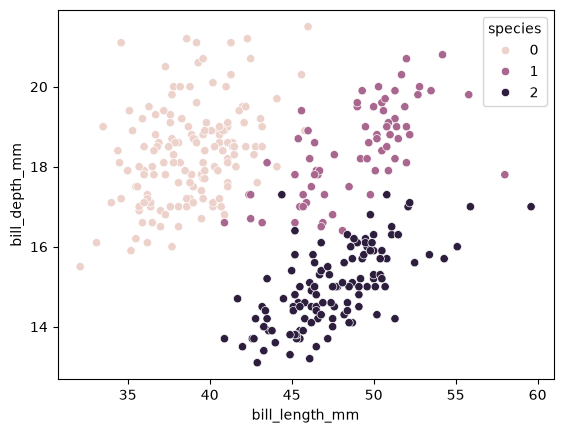

In [9]:
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.show()

## Train

In [10]:
X = df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "bill_ratio",
        "body_mass_scaled",
    ]
]
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 266 samples
Test set size: 67 samples


In [11]:
# Scale features for LogisticRegression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression
# Distance based, so need scaling.
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained.")

Logistic Regression model trained.


In [12]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


In [14]:
# Train Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting model trained.")

Gradient Boosting model trained.


## Evaluate

In [15]:
# Evaluate all three models
models = [
    ("Random Forest", rf_model, X_test),
    ("Logistic Regression", lr_model, X_test_scaled),
    ("Gradient Boosting", gb_model, X_test),
]

results = []
for name, model, X_test_data in models:
    preds = model.predict(X_test_data)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc, preds))
    print(f"{name:25} accuracy: {acc:.4f}")

Random Forest             accuracy: 1.0000
Logistic Regression       accuracy: 1.0000
Gradient Boosting         accuracy: 1.0000


In [16]:
# Find best model
best_name, best_acc, best_preds = max(results, key=lambda x: x[1])
print(f"\nBest model: {best_name} ({best_acc:.4f})")


Best model: Random Forest (1.0000)


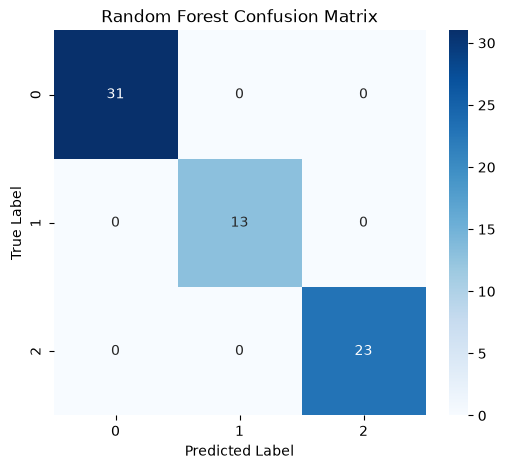

In [17]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_name} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Predict on a new sample

In [18]:
# Use the best model for prediction
sample = {
    "bill_length_mm": 39.5,
    "bill_depth_mm": 17.4,
    "flipper_length_mm": 187,
    "body_mass_g": 3600,
}

sample_df = pd.DataFrame([sample])
sample_df["bill_ratio"] = sample_df["bill_length_mm"] / sample_df["bill_depth_mm"]
sample_df["body_mass_scaled"] = sample_df["body_mass_g"] / 1000
sample_df = sample_df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g",
        "bill_ratio",
        "body_mass_scaled",
    ]
]

# Apply same preprocessing as training
if best_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample_df)
    prediction = lr_model.predict(sample_scaled)[0]
else:
    # RandomForest and GradientBoosting use unscaled features
    prediction = (rf_model if best_name == "Random Forest" else gb_model).predict(
        sample_df
    )[0]

print(f"Using {best_name} model:")
print("Predicted species label:", prediction)
print("Decoded species:", species_encoder.inverse_transform([prediction])[0])

Using Random Forest model:
Predicted species label: 0
Decoded species: Adelie
